In [2]:
%pip install torch

   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   -- ------------------------------------- 7.1/123.0 MB 38.8 MB/s eta 0:00:03
   ------ --------------------------------- 18.9/123.0 MB 47.8 MB/s eta 0:00:03
   ---------- ----------------------------- 32.2/123.0 MB 53.1 MB/s eta 0:00:02
   -------------- ------------------------- 45.1/123.0 MB 57.8 MB/s eta 0:00:02
   ----------------- ---------------------- 55.1/123.0 MB 54.6 MB/s eta 0:00:02
   --------------------- ------------------ 67.4/123.0 MB 55.2 MB/s eta 0:00:02
   ------------------------ --------------- 75.5/123.0 MB 54.0 MB/s eta 0:00:01
   ---------------------------- ----------- 87.3/123.0 MB 53.6 MB/s eta 0:00:01
   ------------------------------- -------- 98.0/123.0 MB 53.2 MB/s eta 0:00:01
   ---------------------------------- ---- 109.6/123.0 MB 53.3 MB/s eta 0:00:01
   --------------------------------------  121.9/123.0 MB 53.6 MB/s eta 0:00:01
   --------------------------------------  122.9/1

In [3]:
import torch
import torch.nn as nn
import numpy as np
import joblib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [4]:
LINK_LENGTH = [100, 333, [117, 358], 100]

def fk(theta):

    A0 = np.array([
        [np.cos(theta[0]), -np.sin(theta[0]), 0, 0],
        [np.sin(theta[0]),  np.cos(theta[0]), 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])

    A1 = np.array([
        [np.cos(theta[1]), 0, -np.sin(theta[1]), LINK_LENGTH[0]],
        [0, 1, 0, 0],
        [np.sin(theta[1]), 0, np.cos(theta[1]), 0],
        [0, 0, 0, 1]
    ])

    theta2_prime = theta[2] + np.radians(71.9)

    A2 = np.array([
        [np.cos(theta2_prime), 0, -np.sin(theta2_prime), 0],
        [0, 1, 0, 0],
        [np.sin(theta2_prime), 0, np.cos(theta2_prime), LINK_LENGTH[1]],
        [0, 0, 0, 1]
    ])

    A3 = np.array([
        [1, 0, 0, LINK_LENGTH[2][0]],
        [0, np.cos(theta[3]), -np.sin(theta[3]), 0],
        [0, np.sin(theta[3]), np.cos(theta[3]), LINK_LENGTH[2][1]],
        [0, 0, 0, 1]
    ])

    A4 = np.array([
        [np.cos(theta[4]), 0, -np.sin(theta[4]), 0],
        [0, 1, 0, 0],
        [np.sin(theta[4]), 0, np.cos(theta[4]), 0],
        [0, 0, 0, 1]
    ])

    A5 = np.array([
        [1, 0, 0, LINK_LENGTH[3]],
        [0, 1, 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])

    T = A0 @ A1 @ A2 @ A3 @ A4 @ A5

    pos = T[:3, 3]

    return pos

def jacobian(theta, eps=1e-6):

    theta = np.asarray(theta, dtype=float)

    J = np.zeros((3, len(theta)))

    p0 = fk(theta)

    for i in range(len(theta)):

        th = theta.copy()
        th[i] += eps

        p1 = fk(th)

        J[:, i] = (p1 - p0) / eps

    return J

def inverse_kinematics(
        target,
        theta_init=None,
        max_iter=1000,
        tolerance=1e-3,
        alpha=0.3):

    if theta_init is None:
        theta = np.zeros(5)
    else:
        theta = np.array(theta_init, dtype=float)



    for i in range(max_iter):

        current = fk(theta)

        error = target - current

        if np.linalg.norm(error) < tolerance:
            print(f"Converged in {i} iterations")
            return theta

        J = jacobian(theta)

        dtheta = alpha * np.linalg.pinv(J) @ error

        theta += dtheta

    print("Failed to converge")
    return theta

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")

class IK_model(nn.Module):
    def __init__(self):
        super(IK_model, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(6, 256),
            nn.SiLU(),
            nn.BatchNorm1d(256),

            nn.Linear(256, 512),
            nn.SiLU(),
            nn.BatchNorm1d(512),

            nn.Linear(512, 512),
            nn.SiLU(),
            nn.BatchNorm1d(512),

            nn.Linear(512, 256),
            nn.SiLU(),
            nn.BatchNorm1d(256),

            nn.Linear(256, 5)
        )

    def forward(self, x):
        return self.network(x)

class WeightedIKLoss(nn.Module):
  def __init__(self, device):
      super(WeightedIKLoss, self).__init__()
      self.weights = torch.tensor([15.0, 8.0, 7.5, 1.5, 1.0], dtype=torch.float32).to(device) # 링크 길이에 따라 차등적으로 loss 부여 ( 앞쪽 링크일수록 최종 값에 영향을 더 많이 주니까.. )

  def forward(self, pred, true):
      loss_per_element = (pred - true) ** 2

      weighted_loss = loss_per_element * self.weights

      return torch.mean(weighted_loss)

device: cpu


Converged in 35 iterations
no 01 | jacobian = 0.00 mm | torch prediction = 11.29 mm
Converged in 35 iterations
no 02 | jacobian = 0.00 mm | torch prediction = 8.14 mm
Converged in 37 iterations
no 03 | jacobian = 0.00 mm | torch prediction = 26.22 mm
Converged in 142 iterations
no 04 | jacobian = 0.00 mm | torch prediction = 21.28 mm
Converged in 39 iterations
no 05 | jacobian = 0.00 mm | torch prediction = 15.92 mm
Converged in 39 iterations
no 06 | jacobian = 0.00 mm | torch prediction = 7.62 mm
Converged in 35 iterations
no 07 | jacobian = 0.00 mm | torch prediction = 12.38 mm
Converged in 37 iterations
no 08 | jacobian = 0.00 mm | torch prediction = 8.94 mm
Converged in 37 iterations
no 09 | jacobian = 0.00 mm | torch prediction = 4.79 mm
Converged in 40 iterations
no 10 | jacobian = 0.00 mm | torch prediction = 15.99 mm


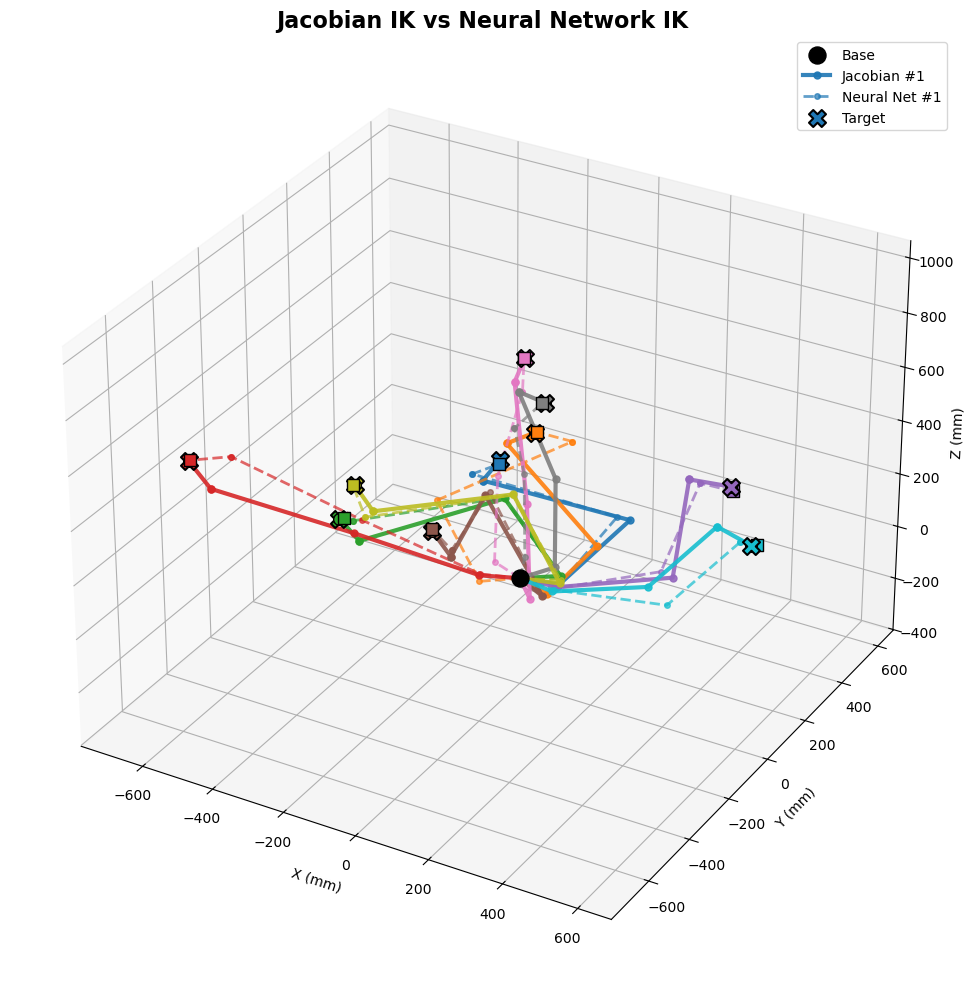

In [25]:
def get_trans(theta, link_length):
    A0 = np.array([
        [np.cos(theta[0]), -np.sin(theta[0]), 0, 0],
        [np.sin(theta[0]),  np.cos(theta[0]), 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])

    A1 = np.array([
        [np.cos(theta[1]), 0, -np.sin(theta[1]), link_length[0]],
        [0, 1, 0, 0],
        [np.sin(theta[1]), 0, np.cos(theta[1]), 0],
        [0, 0, 0, 1]
    ])

    theta2_prime = theta[2] + np.radians(71.9)

    A2 = np.array([
        [np.cos(theta2_prime), 0, -np.sin(theta2_prime), 0],
        [0, 1, 0, 0],
        [np.sin(theta2_prime), 0, np.cos(theta2_prime), link_length[1]],
        [0, 0, 0, 1]
    ])

    A3 = np.array([
        [1, 0, 0, link_length[2][0]],
        [0, np.cos(theta[3]), -np.sin(theta[3]), 0],
        [0, np.sin(theta[3]), np.cos(theta[3]), link_length[2][1]],
        [0, 0, 0, 1]
    ])

    A4 = np.array([
        [np.cos(theta[4]), 0, -np.sin(theta[4]), 0],
        [0, 1, 0, 0],
        [np.sin(theta[4]), 0, np.cos(theta[4]), 0],
        [0, 0, 0, 1]
    ])

    A5 = np.array([
        [1, 0, 0, link_length[3]],
        [0, 1, 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1],
    ])

    A = [A0, A1, A2, A3, A4, A5]
    T = np.eye(4)
    joints = [[0, 0, 0]]

    for Ai in A:
        T = T @ Ai
        joints.append(T[:3, 3].copy())

    return np.array(joints)

def plot_compare_robot_arms(
    jacobian_joints_list,
    nn_joints_list,
    target_list
): # made with chat-GPT.. i think matplotlib is too hard for me >:
    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')

    colors = plt.cm.tab10(
        np.linspace(0, 1, len(target_list))
    )

    all_points = []

    ax.scatter(
        0, 0, 0,
        color='black',
        s=150,
        label='Base'
    )

    for idx, (jac, nn, target) in enumerate(
        zip(jacobian_joints_list, nn_joints_list, target_list)
    ):
        color = colors[idx]

        ax.plot(
            jac[:, 0],
            jac[:, 1],
            jac[:, 2],
            '-o',
            color=color,
            linewidth=3,
            markersize=5,
            alpha=0.9,
            label=f'Jacobian #{idx+1}' if idx == 0 else None
        )

        ax.plot(
            nn[:, 0],
            nn[:, 1],
            nn[:, 2],
            '--o',
            color=color,
            linewidth=2,
            markersize=4,
            alpha=0.7,
            label=f'Neural Net #{idx+1}' if idx == 0 else None
        )

        ax.scatter(
            target[0],
            target[1],
            target[2],
            marker='X',
            s=150,
            color=color,
            edgecolors='black',
            linewidths=1.5,
            label='Target' if idx == 0 else None
        )

        ax.scatter(
            jac[-1, 0],
            jac[-1, 1],
            jac[-1, 2],
            s=70,
            color=color,
            edgecolors='black'
        )

        ax.scatter(
            nn[-1, 0],
            nn[-1, 1],
            nn[-1, 2],
            s=70,
            color=color,
            marker='s',
            edgecolors='black'
        )

        ax.plot(
            [jac[-1, 0], target[0]],
            [jac[-1, 1], target[1]],
            [jac[-1, 2], target[2]],
            color='green',
            linewidth=1,
            alpha=0.6
        )

        ax.plot(
            [nn[-1, 0], target[0]],
            [nn[-1, 1], target[1]],
            [nn[-1, 2], target[2]],
            color='red',
            linewidth=1,
            alpha=0.6
        )

        all_points.extend(jac)
        all_points.extend(nn)
        all_points.append(target)

    all_points = np.array(all_points)

    x = all_points[:, 0]
    y = all_points[:, 1]
    z = all_points[:, 2]

    max_range = np.array([
        x.max() - x.min(),
        y.max() - y.min(),
        z.max() - z.min()
    ]).max() / 2

    mid_x = (x.max() + x.min()) / 2
    mid_y = (y.max() + y.min()) / 2
    mid_z = (z.max() + z.min()) / 2

    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)

    ax.set_xlabel("X (mm)")
    ax.set_ylabel("Y (mm)")
    ax.set_zlabel("Z (mm)")

    ax.set_title(
        "Jacobian IK vs Neural Network IK",
        fontsize=16,
        fontweight='bold'
    )

    ax.grid(True)
    ax.legend()
    plt.tight_layout()
    plt.show()

def get_valid_random_target(link_lengths, min_dist=400.0, max_dist=900.0):
    max_rotation = [180, 50, 75, 90, 60]
    min_rotation = [-180, -90, -75, -90, -60]

    min_limits = np.radians(min_rotation)
    max_limits = np.radians(max_rotation)

    while True:
        rand_theta = [np.random.uniform(min_limits[i], max_limits[i]) for i in range(5)]
        joints = get_trans(rand_theta, link_lengths)
        ee_pure = joints[-1]

        distance = np.linalg.norm(ee_pure)

        if min_dist <= distance <= max_dist:
            A0 = np.array([[np.cos(rand_theta[0]), -np.sin(rand_theta[0]), 0, 0], [np.sin(rand_theta[0]), np.cos(rand_theta[0]), 0, 0], [0,0,1,0], [0,0,0,1]])
            A1 = np.array([[np.cos(rand_theta[1]), 0, -np.sin(rand_theta[1]), link_lengths[0]], [0,1,0,0], [np.sin(rand_theta[1]), 0, np.cos(rand_theta[1]), 0], [0,0,0,1]])
            A2 = np.array([[np.cos(rand_theta[2]+np.radians(71.9)), 0, -np.sin(rand_theta[2]+np.radians(71.9)), 0], [0,1,0,0], [np.sin(rand_theta[2]+np.radians(71.9)), 0, np.cos(rand_theta[2]+np.radians(71.9)), link_lengths[1]], [0,0,0,1]])
            A3 = np.array([[1,0,0,link_lengths[2][0]], [0,np.cos(rand_theta[3]),-np.sin(rand_theta[3]),0], [0,np.sin(rand_theta[3]),np.cos(rand_theta[3]),link_lengths[2][1]], [0,0,0,1]])
            A4 = np.array([[np.cos(rand_theta[4]), 0, -np.sin(rand_theta[4]), 0], [0,1,0,0], [np.sin(rand_theta[4]), 0, np.cos(rand_theta[4]), 0], [0,0,0,1]])
            A5 = np.array([[1,0,0,link_lengths[3]], [0,1,0,0], [0,0,1,0], [0,0,0,1]])
            T = A0 @ A1 @ A2 @ A3 @ A4 @ A5

            r11, r21, r31 = T[0, 0], T[1, 0], T[2, 0]
            r32, r33 = T[2, 1], T[2, 2]

            yaw = np.arctan2(r21, r11)
            pitch = np.arctan2(-r31, np.sqrt(r32**2 + r33**2))
            roll = np.arctan2(r32, r33)

            target_pos = [ee_pure[0], ee_pure[1], ee_pure[2], roll, pitch, yaw]
            return target_pos

def main():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    try:
        scaler = joblib.load('ik_scaler.pkl')
        model = IK_model().to(device)
        model.load_state_dict(torch.load('JeongMan6 model.pth', map_location=device))
        model.eval()
    except FileNotFoundError as e:
        print(f"fucking file err: {e}")
        return

    link_lengths = [100, 333, [117, 358], 100]

    target_list = []
    jacobian_joints_list = []
    nn_joints_list = []

    for i in range(10):
        target_position = get_valid_random_target(link_lengths, min_dist=400.0, max_dist=900.0)
        target_list.append(target_position)

        # jacobian
        target_xyz = np.array(target_position[:3])

        jacobian_theta = inverse_kinematics(
            target_xyz,
            theta_init=np.radians([0, 0, 0, 0, 0])
        )

        jacobian_joint_positions = get_trans(jacobian_theta, link_lengths)
        jacobian_joints_list.append(jacobian_joint_positions)


        # torch prediction
        target_array = np.array([target_position])
        scaled_input = scaler.transform(target_array)

        input_tensor = torch.tensor(
            scaled_input,
            dtype=torch.float32
        ).to(device)

        with torch.no_grad():
            nn_theta = model(input_tensor)
            nn_theta = nn_theta.cpu().numpy().flatten()

        nn_joint_positions = get_trans(nn_theta, link_lengths)
        nn_joints_list.append(nn_joint_positions)

        jacobian_error = np.linalg.norm(
            jacobian_joint_positions[-1] - target_xyz
        )

        nn_error = np.linalg.norm(
            nn_joint_positions[-1] - target_xyz
        )

        print(f"no {i+1:02d} | " f"jacobian = {jacobian_error:.2f} mm | " f"torch prediction = {nn_error:.2f} mm")
        
    plot_compare_robot_arms(
        jacobian_joints_list,
        nn_joints_list,
        [t[:3] for t in target_list]
    )

if __name__ == "__main__":
    main()

In [16]:
import os

print(os.listdir())

['.git', 'assets', 'compare.ipynb', 'ik_scaler.pkl', 'jacobian.tex', 'jacobian_elements.tex', 'JeongMan6 model.pth', 'JeongMan6_data_generator.ipynb', 'JeongMan6_inversed_kinematiccc.ipynb', 'JeongMan6_linear_model.ipynb', 'main_controll.py', 'model', 'README.md']
